# Dual-Channel Fast-PL Visualization Workflow

This notebook is the detailed visualization workflow for the dual-channel fast-PL correction.

## Goal
The final product is a corrected NV PL readout:

- `PL_C`: laser-reference photodiode
- `PL_D`: NV photoluminescence photodiode
- `corrected_nv_adc`: NV PL with the matched laser common-mode drift/noise removed

The notebook exposes every stage explicitly:

1. raw simultaneous data in native ADC units
2. baseline means and scale difference between channels
3. centered and fractional-normalized channels
4. low-pass extraction of the shared low-frequency fluctuation
5. proportional scaling from `PL_C` fluctuation into the `PL_D` scale
6. reconstructed common-mode term in NV ADC units
7. final corrected NV PL readout
8. export of the corrected readout to CSV

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import butter, coherence, filtfilt, welch

plt.style.use('default')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [2]:
ROOT = Path('/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer')
DATASETS = {
    'laser_on': ROOT / 'Initial Test/fast_PL_dual_channel_laser_5000.csv',
    'laser_off_ref_off': ROOT / 'Initial Test/fast_PL_dual_channel_no_laser.csv',
}

REFERENCE_COL = 'PL_C'
SIGNAL_COL = 'PL_D'
DEFAULT_LOWPASS_CUTOFF_HZ = 20.0
EXPORT_DIR = ROOT / 'Initial Test'

for name, file_path in DATASETS.items():
    print(f'{name:>18}: {file_path}')
print(f'\nExport directory: {EXPORT_DIR}')

          laser_on: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/Initial Test/fast_PL_dual_channel_laser_5000.csv
 laser_off_ref_off: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/Initial Test/fast_PL_dual_channel_no_laser.csv

Export directory: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/Initial Test


In [3]:
@dataclass
class DualChannelWorkflow:
    label: str
    sample_rate_hz: float
    cutoff_hz: float
    reference_mean: float
    signal_mean: float
    alpha: float
    corr_lowband: float
    mean_coherence_0_50_hz: float
    bypass: bool
    mode: str
    dataframe: pd.DataFrame


def infer_sample_rate_hz(time_s: np.ndarray) -> float:
    """Return the dominant slow-window sample rate.

    Datasets with interleaved fast/slow acquisition windows contain two
    distinct dt populations.  Using median or mode directly can resolve
    to the fast-window rate, which produces an absurdly high normalised
    cutoff for the LP filter.  Instead, find all dt values that account
    for at least 5 % of samples and pick the *largest* one, which
    corresponds to the slow (laser-drift measurement) window.
    """
    dts = np.diff(time_s)
    rounded_us = np.round(dts * 1e6).astype(int)
    unique, counts = np.unique(rounded_us, return_counts=True)
    threshold = 0.05 * len(dts)
    common = unique[counts >= threshold]
    dominant_us = int(common.max()) if len(common) else int(unique[np.argmax(counts)])
    return float(1e6 / dominant_us)


def fractional_fluctuation(signal: np.ndarray) -> tuple[np.ndarray, float]:
    mean_value = float(np.mean(signal))
    return (signal - mean_value) / mean_value, mean_value


def lowpass(signal: np.ndarray, sample_rate_hz: float, cutoff_hz: float, order: int = 3) -> np.ndarray:
    nyquist_hz = 0.5 * sample_rate_hz
    normalized_cutoff = min(cutoff_hz / nyquist_hz, 0.99)
    b, a = butter(order, normalized_cutoff, btype='low')
    return filtfilt(b, a, signal)


def lowpass_nonuniform(
    signal: np.ndarray,
    time_s: np.ndarray,
    sample_rate_hz: float,
    cutoff_hz: float,
    order: int = 3,
) -> np.ndarray:
    """LP filter for non-uniformly sampled data.

    Resamples to a uniform grid at *sample_rate_hz* (the mode dt rate),
    applies a zero-phase Butterworth filter, then interpolates the
    filtered result back to the original (non-uniform) timestamps.
    This prevents the Butterworth from seeing spurious fast edges that
    arise when slow and fast acquisition windows are interleaved.
    """
    t0, t1 = float(time_s[0]), float(time_s[-1])
    n_uniform = max(2, int(round((t1 - t0) * sample_rate_hz)) + 1)
    t_uniform = np.linspace(t0, t1, n_uniform)
    signal_uniform = interp1d(time_s, signal, kind='linear',
                              bounds_error=False, fill_value='extrapolate')(t_uniform)
    filtered_uniform = lowpass(signal_uniform, sample_rate_hz, cutoff_hz, order)
    return interp1d(t_uniform, filtered_uniform, kind='linear',
                    bounds_error=False, fill_value='extrapolate')(time_s)


def mean_band_coherence(signal: np.ndarray, reference: np.ndarray, sample_rate_hz: float, band=(0.0, 50.0)) -> float:
    freqs, coh = coherence(signal, reference, fs=sample_rate_hz, nperseg=min(2048, len(signal)))
    lo, hi = band
    mask = (freqs >= lo) & (freqs < hi)
    if not np.any(mask):
        return 0.0
    return float(np.nanmean(coh[mask]))


def bandpower(signal: np.ndarray, sample_rate_hz: float, band: tuple[float, float]) -> float:
    freqs, psd = welch(signal, fs=sample_rate_hz, nperseg=min(4096, len(signal)))
    lo, hi = band
    mask = (freqs >= lo) & (freqs < hi)
    if not np.any(mask):
        return 0.0
    return float(np.trapezoid(psd[mask], freqs[mask]))


def build_workflow(csv_path: Path, *, label: str, cutoff_hz: float = DEFAULT_LOWPASS_CUTOFF_HZ) -> DualChannelWorkflow:
    df = pd.read_csv(csv_path).copy()

    time_s = df['time_s'].to_numpy(float)
    reference_raw = df[REFERENCE_COL].to_numpy(float)
    signal_raw = df[SIGNAL_COL].to_numpy(float)
    sample_rate_hz = infer_sample_rate_hz(time_s)

    reference_fractional, reference_mean = fractional_fluctuation(reference_raw)
    signal_fractional, signal_mean = fractional_fluctuation(signal_raw)

    reference_fractional_low = lowpass_nonuniform(reference_fractional, time_s, sample_rate_hz, cutoff_hz)
    signal_fractional_low = lowpass_nonuniform(signal_fractional, time_s, sample_rate_hz, cutoff_hz)

    alpha = float(np.dot(reference_fractional_low, signal_fractional_low) / np.dot(reference_fractional_low, reference_fractional_low))
    corr_lowband = float(np.corrcoef(signal_fractional_low, reference_fractional_low)[0, 1])
    mean_coh = mean_band_coherence(signal_fractional, reference_fractional, sample_rate_hz, band=(0.0, cutoff_hz))

    bypass = (abs(corr_lowband) < 0.15) and (mean_coh < 0.20)
    mode = 'bypass' if bypass else 'proportional_lowband'

    if bypass:
        common_mode_nv_adc = np.zeros_like(signal_raw)
        corrected_nv_adc = signal_raw.copy()
        matched_reference_in_nv_adc = np.full_like(signal_raw, signal_mean)
    else:
        common_mode_nv_adc = alpha * signal_mean * reference_fractional_low
        corrected_nv_adc = signal_raw - common_mode_nv_adc
        matched_reference_in_nv_adc = signal_mean + common_mode_nv_adc

    df['reference_raw_adc'] = reference_raw
    df['signal_raw_adc'] = signal_raw
    df['reference_mean_adc'] = reference_mean
    df['signal_mean_adc'] = signal_mean
    df['reference_fractional'] = reference_fractional
    df['signal_fractional'] = signal_fractional
    df['reference_fractional_low'] = reference_fractional_low
    df['signal_fractional_low'] = signal_fractional_low
    df['scaled_reference_fractional_low'] = alpha * reference_fractional_low
    df['common_mode_nv_adc'] = common_mode_nv_adc
    df['matched_reference_in_nv_adc'] = matched_reference_in_nv_adc
    df['corrected_nv_adc'] = corrected_nv_adc
    df['removed_component_adc'] = signal_raw - corrected_nv_adc

    return DualChannelWorkflow(
        label=label,
        sample_rate_hz=sample_rate_hz,
        cutoff_hz=float(cutoff_hz),
        reference_mean=reference_mean,
        signal_mean=signal_mean,
        alpha=alpha,
        corr_lowband=corr_lowband,
        mean_coherence_0_50_hz=mean_coh,
        bypass=bool(bypass),
        mode=mode,
        dataframe=df,
    )


def workflow_summary(result: DualChannelWorkflow) -> pd.DataFrame:
    df = result.dataframe
    return pd.DataFrame([{
        'label': result.label,
        'sample_rate_hz': result.sample_rate_hz,
        'cutoff_hz': result.cutoff_hz,
        'mode': result.mode,
        'alpha': result.alpha,
        'corr_lowband': result.corr_lowband,
        'mean_coherence_0_50_hz': result.mean_coherence_0_50_hz,
        'raw_mean_adc': float(df['signal_raw_adc'].mean()),
        'corrected_mean_adc': float(df['corrected_nv_adc'].mean()),
        'raw_std_adc': float(df['signal_raw_adc'].std(ddof=0)),
        'corrected_std_adc': float(df['corrected_nv_adc'].std(ddof=0)),
        'raw_bp_0_10': bandpower(df['signal_raw_adc'].to_numpy(float), result.sample_rate_hz, (0.0, 10.0)),
        'corrected_bp_0_10': bandpower(df['corrected_nv_adc'].to_numpy(float), result.sample_rate_hz, (0.0, 10.0)),
        'raw_bp_10_50': bandpower(df['signal_raw_adc'].to_numpy(float), result.sample_rate_hz, (10.0, 50.0)),
        'corrected_bp_10_50': bandpower(df['corrected_nv_adc'].to_numpy(float), result.sample_rate_hz, (10.0, 50.0)),
        'raw_bp_50_200': bandpower(df['signal_raw_adc'].to_numpy(float), result.sample_rate_hz, (50.0, 200.0)),
        'corrected_bp_50_200': bandpower(df['corrected_nv_adc'].to_numpy(float), result.sample_rate_hz, (50.0, 200.0)),
    }])

## Build Both Workflows

The first result is the laser-on correction path. The second is the reference-off control that should remain in bypass.

In [4]:
laser_on = build_workflow(DATASETS['laser_on'], label='fast_PL_dual_channel_laser', cutoff_hz=DEFAULT_LOWPASS_CUTOFF_HZ)
laser_off_ref_off = build_workflow(DATASETS['laser_off_ref_off'], label='fast_PL_dual_channel_no_laser_2ndPD_off', cutoff_hz=DEFAULT_LOWPASS_CUTOFF_HZ)

summary_df = pd.concat([
    workflow_summary(laser_on),
    workflow_summary(laser_off_ref_off),
], ignore_index=True)
summary_df['std_improvement_pct'] = (1.0 - summary_df['corrected_std_adc'] / summary_df['raw_std_adc']) * 100.0
summary_df['bp_0_10_improvement_pct'] = (1.0 - summary_df['corrected_bp_0_10'] / summary_df['raw_bp_0_10']) * 100.0
summary_df['bp_10_50_improvement_pct'] = (1.0 - summary_df['corrected_bp_10_50'] / summary_df['raw_bp_10_50']) * 100.0
summary_df.round(4)

,label,sample_rate_hz,cutoff_hz,mode,alpha,corr_lowband,mean_coherence_0_50_hz,raw_mean_adc,corrected_mean_adc,raw_std_adc,corrected_std_adc,raw_bp_0_10,corrected_bp_0_10,raw_bp_10_50,corrected_bp_10_50,raw_bp_50_200,corrected_bp_50_200,std_improvement_pct,bp_0_10_improvement_pct,bp_10_50_improvement_pct
0,fast_PL_dual_channel_laser,4587.1560,20.0,proportional_lowband,-0.0027,-0.2108,0.1061,5250.2935,5250.2836,2.9366,2.9240,0.4975,0.4923,0.8980,0.8959,1.3597,1.3597,0.4288,1.0605,0.23
1,fast_PL_dual_channel_no_laser_2ndPD_off,4694.8357,20.0,bypass,-0.0074,-0.0979,0.0389,-605.7244,-605.7244,1.4802,1.4802,0.1203,0.1203,0.1312,0.1312,0.2883,0.2883,0.0000,0.0000,0.00


## Step 1: Raw Simultaneous Data

Plot the two channels exactly as acquired. The main point here is that the DC scales are very different, so the algorithm should not subtract the raw `PL_C` level directly from `PL_D`.

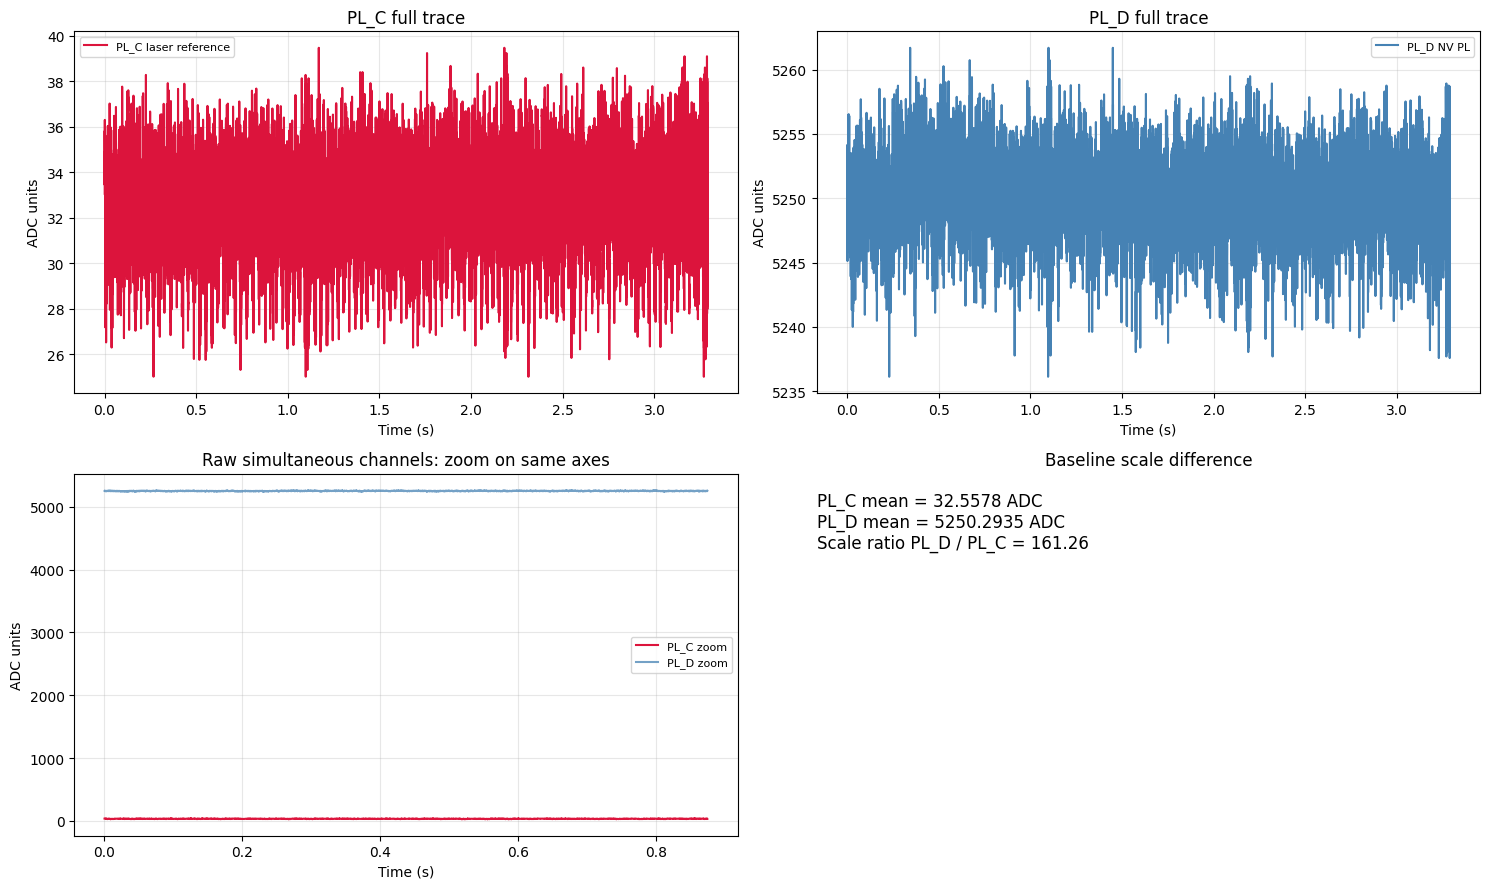

In [5]:
res = laser_on.dataframe
sl = slice(0, min(4000, len(res)))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(res['time_s'], res['reference_raw_adc'], color='crimson', label='PL_C laser reference')
axes[0, 0].set_title('PL_C full trace')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('ADC units')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(res['time_s'], res['signal_raw_adc'], color='steelblue', label='PL_D NV PL')
axes[0, 1].set_title('PL_D full trace')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('ADC units')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(res['time_s'].to_numpy(float)[sl], res['reference_raw_adc'].to_numpy(float)[sl], color='crimson', label='PL_C zoom')
axes[1, 0].plot(res['time_s'].to_numpy(float)[sl], res['signal_raw_adc'].to_numpy(float)[sl], color='steelblue', label='PL_D zoom', alpha=0.75)
axes[1, 0].set_title('Raw simultaneous channels: zoom on same axes')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('ADC units')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=8)

axes[1, 1].axis('off')
axes[1, 1].text(
    0.0,
    0.95,
    '\n'.join([
        f'PL_C mean = {laser_on.reference_mean:.4f} ADC',
        f'PL_D mean = {laser_on.signal_mean:.4f} ADC',
        f'Scale ratio PL_D / PL_C = {laser_on.signal_mean / laser_on.reference_mean:.2f}',
    ]),
    va='top',
    fontsize=12,
)
axes[1, 1].set_title('Baseline scale difference')

plt.tight_layout()
plt.show()

## Step 2: Fractional Scaling

Each channel is converted to deviation from its own mean and then normalized by that mean. This is the step that makes the two channels directly comparable.

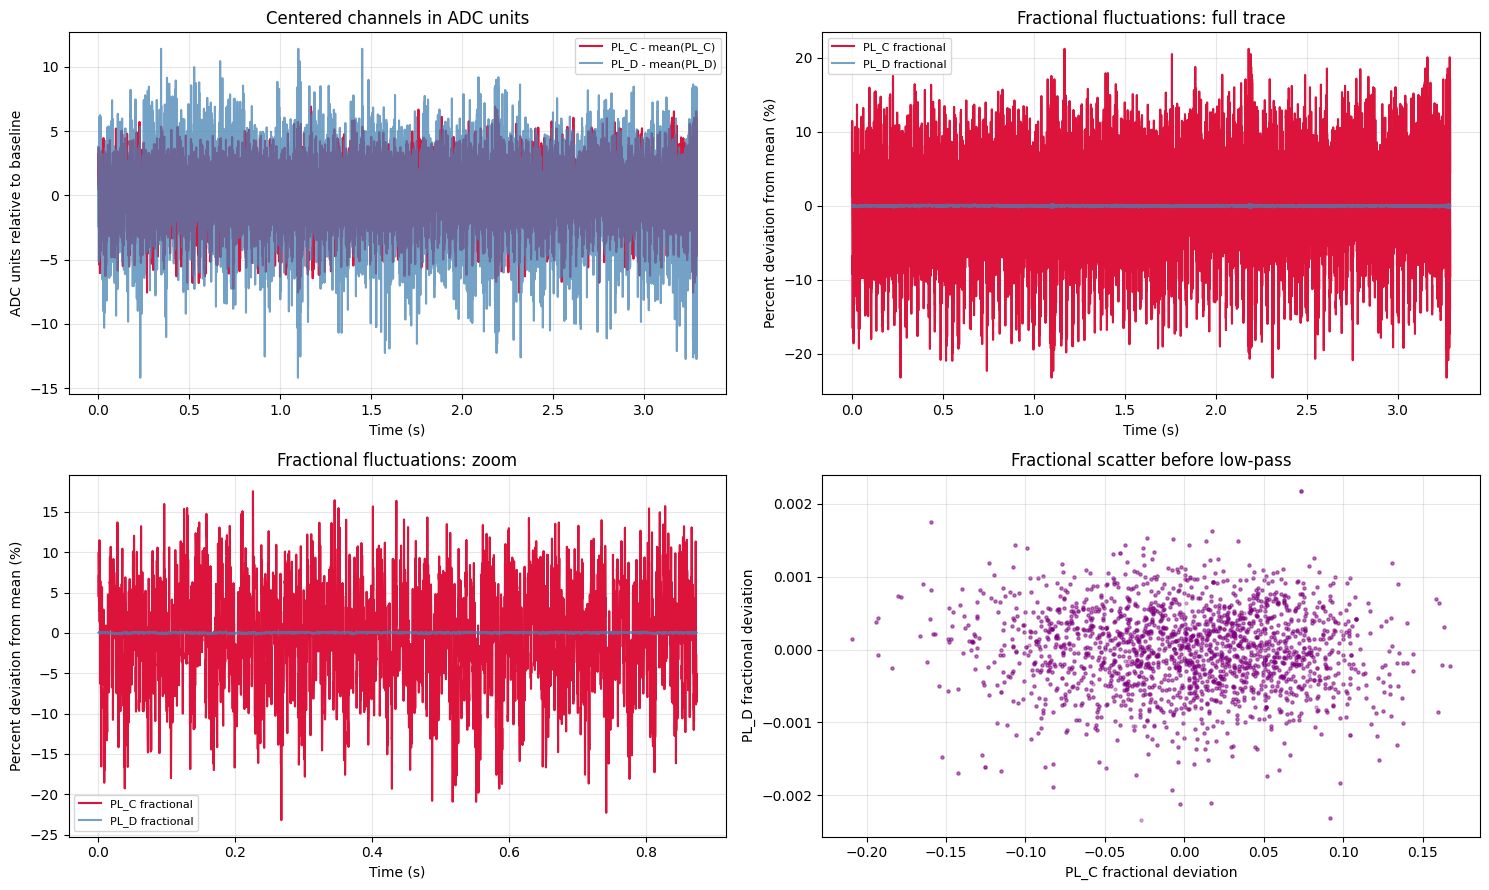

In [6]:
res = laser_on.dataframe
sl = slice(0, min(4000, len(res)))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(res['time_s'], res['reference_raw_adc'] - laser_on.reference_mean, color='crimson', label='PL_C - mean(PL_C)')
axes[0, 0].plot(res['time_s'], res['signal_raw_adc'] - laser_on.signal_mean, color='steelblue', label='PL_D - mean(PL_D)', alpha=0.75)
axes[0, 0].set_title('Centered channels in ADC units')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('ADC units relative to baseline')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(res['time_s'], 100 * res['reference_fractional'], color='crimson', label='PL_C fractional')
axes[0, 1].plot(res['time_s'], 100 * res['signal_fractional'], color='steelblue', label='PL_D fractional', alpha=0.75)
axes[0, 1].set_title('Fractional fluctuations: full trace')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Percent deviation from mean (%)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(res['time_s'].to_numpy(float)[sl], 100 * res['reference_fractional'].to_numpy(float)[sl], color='crimson', label='PL_C fractional')
axes[1, 0].plot(res['time_s'].to_numpy(float)[sl], 100 * res['signal_fractional'].to_numpy(float)[sl], color='steelblue', label='PL_D fractional', alpha=0.75)
axes[1, 0].set_title('Fractional fluctuations: zoom')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Percent deviation from mean (%)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=8)

axes[1, 1].scatter(res['reference_fractional'][::8], res['signal_fractional'][::8], s=5, alpha=0.3, color='purple')
axes[1, 1].set_title('Fractional scatter before low-pass')
axes[1, 1].set_xlabel('PL_C fractional deviation')
axes[1, 1].set_ylabel('PL_D fractional deviation')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 3: Low-Pass Extraction and Proportional Fit

The shared laser drift is mainly low-frequency. The low-pass traces are the actual quantities used for fitting the proportional coupling `alpha`.

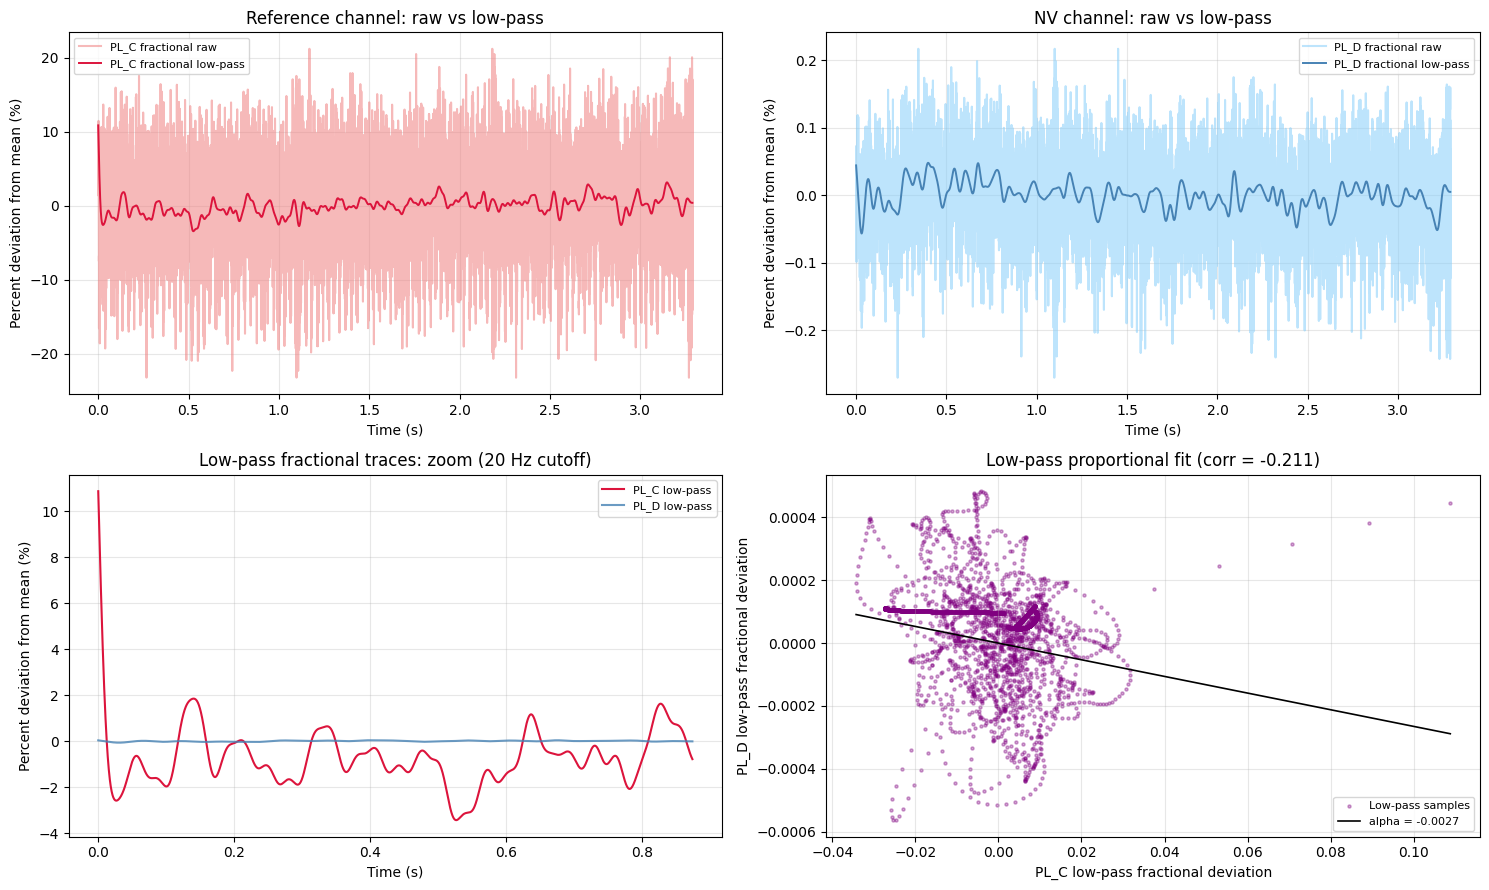

In [7]:
res = laser_on.dataframe
sl = slice(0, min(4000, len(res)))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(res['time_s'], 100 * res['reference_fractional'], color='lightcoral', alpha=0.55, label='PL_C fractional raw')
axes[0, 0].plot(res['time_s'], 100 * res['reference_fractional_low'], color='crimson', linewidth=1.4, label='PL_C fractional low-pass')
axes[0, 0].set_title('Reference channel: raw vs low-pass')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Percent deviation from mean (%)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(res['time_s'], 100 * res['signal_fractional'], color='lightskyblue', alpha=0.55, label='PL_D fractional raw')
axes[0, 1].plot(res['time_s'], 100 * res['signal_fractional_low'], color='steelblue', linewidth=1.4, label='PL_D fractional low-pass')
axes[0, 1].set_title('NV channel: raw vs low-pass')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Percent deviation from mean (%)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(res['time_s'].to_numpy(float)[sl], 100 * res['reference_fractional_low'].to_numpy(float)[sl], color='crimson', label='PL_C low-pass')
axes[1, 0].plot(res['time_s'].to_numpy(float)[sl], 100 * res['signal_fractional_low'].to_numpy(float)[sl], color='steelblue', label='PL_D low-pass', alpha=0.8)
axes[1, 0].set_title(f'Low-pass fractional traces: zoom ({laser_on.cutoff_hz:.0f} Hz cutoff)')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Percent deviation from mean (%)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=8)

x = res['reference_fractional_low'].to_numpy(float)
y = res['signal_fractional_low'].to_numpy(float)
line_x = np.linspace(x.min(), x.max(), 200)
line_y = laser_on.alpha * line_x
axes[1, 1].scatter(x[::8], y[::8], s=5, alpha=0.35, color='purple', label='Low-pass samples')
axes[1, 1].plot(line_x, line_y, color='black', linewidth=1.2, label=f'alpha = {laser_on.alpha:.4f}')
axes[1, 1].set_title(f'Low-pass proportional fit (corr = {laser_on.corr_lowband:.3f})')
axes[1, 1].set_xlabel('PL_C low-pass fractional deviation')
axes[1, 1].set_ylabel('PL_D low-pass fractional deviation')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 4: Common-Mode Term Reconstructed in NV Units

The fitted low-band reference fluctuation is converted into the NV scale. This reconstructed term is exactly what gets removed from the raw NV trace.

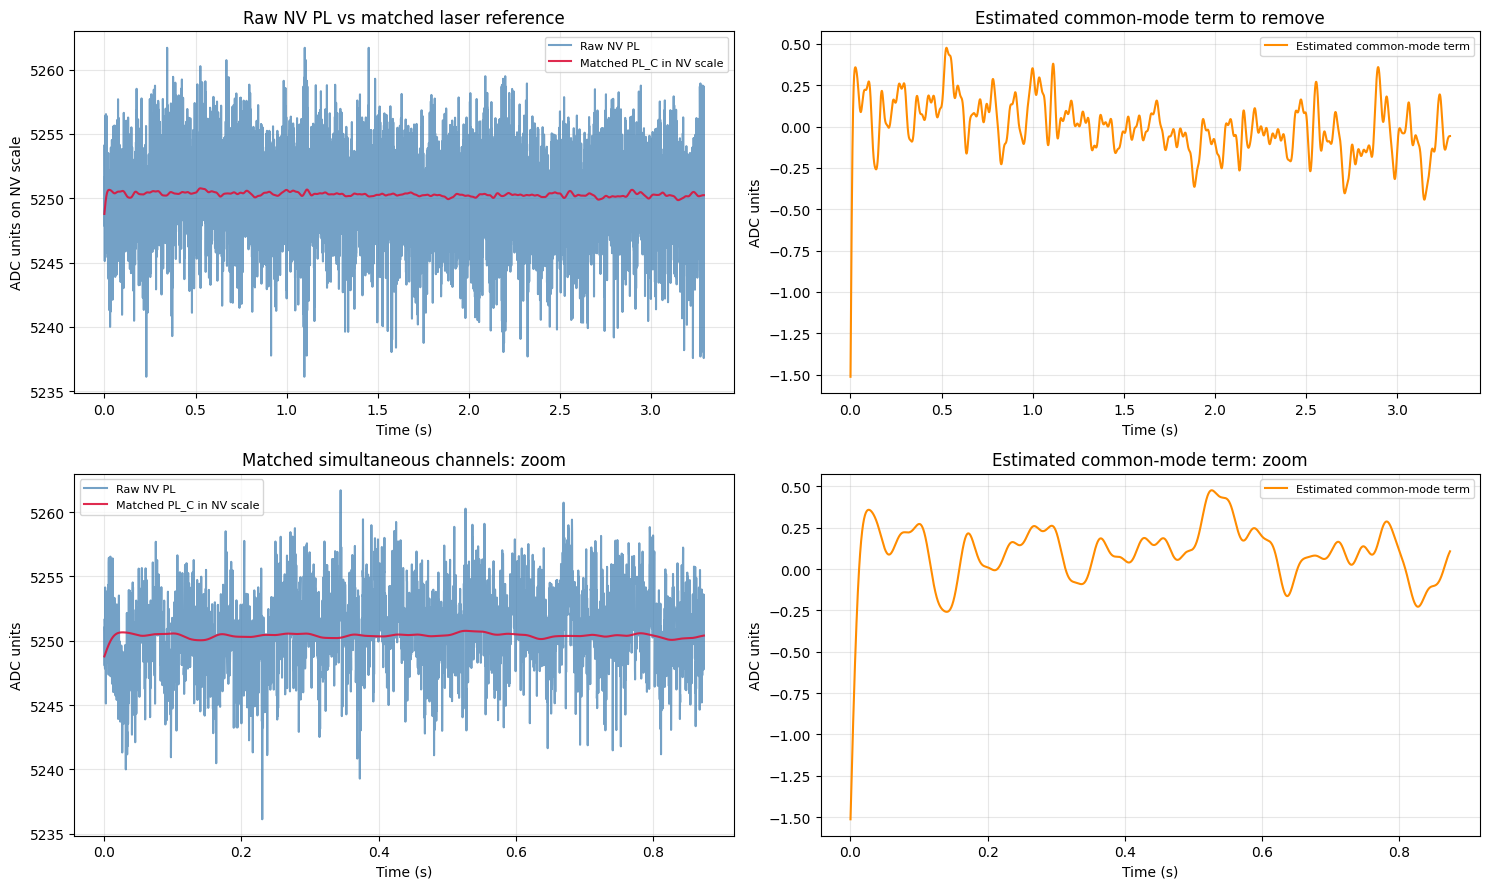

In [8]:
res = laser_on.dataframe
sl = slice(0, min(4000, len(res)))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(res['time_s'], res['signal_raw_adc'], color='steelblue', alpha=0.75, label='Raw NV PL')
axes[0, 0].plot(res['time_s'], res['matched_reference_in_nv_adc'], color='crimson', alpha=0.9, label='Matched PL_C in NV scale')
axes[0, 0].set_title('Raw NV PL vs matched laser reference')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('ADC units on NV scale')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(res['time_s'], res['common_mode_nv_adc'], color='darkorange', label='Estimated common-mode term')
axes[0, 1].set_title('Estimated common-mode term to remove')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('ADC units')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(res['time_s'].to_numpy(float)[sl], res['signal_raw_adc'].to_numpy(float)[sl], color='steelblue', alpha=0.75, label='Raw NV PL')
axes[1, 0].plot(res['time_s'].to_numpy(float)[sl], res['matched_reference_in_nv_adc'].to_numpy(float)[sl], color='crimson', alpha=0.9, label='Matched PL_C in NV scale')
axes[1, 0].set_title('Matched simultaneous channels: zoom')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('ADC units')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(res['time_s'].to_numpy(float)[sl], res['common_mode_nv_adc'].to_numpy(float)[sl], color='darkorange', label='Estimated common-mode term')
axes[1, 1].set_title('Estimated common-mode term: zoom')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('ADC units')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 5: Final Corrected Readout

This is the actual result of the dual-channel correction. The corrected trace is still on the native `PL_D` scale and is the best estimate of purely NV PL after removing the matched laser common mode.

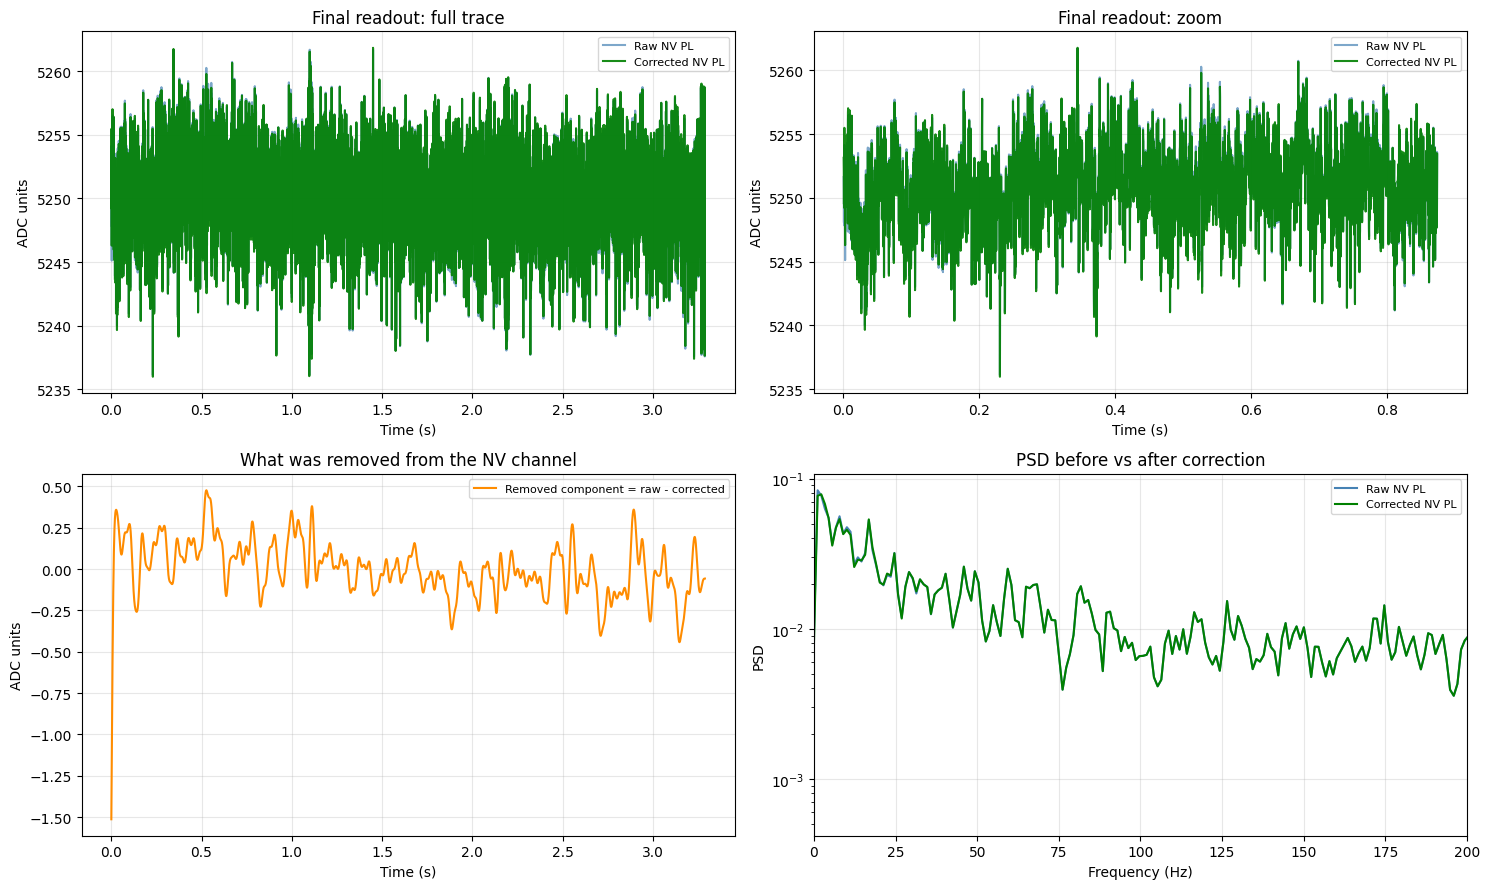

In [9]:
res = laser_on.dataframe
sl = slice(0, min(4000, len(res)))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(res['time_s'], res['signal_raw_adc'], color='steelblue', alpha=0.7, label='Raw NV PL')
axes[0, 0].plot(res['time_s'], res['corrected_nv_adc'], color='green', alpha=0.9, label='Corrected NV PL')
axes[0, 0].set_title('Final readout: full trace')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('ADC units')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(res['time_s'].to_numpy(float)[sl], res['signal_raw_adc'].to_numpy(float)[sl], color='steelblue', alpha=0.7, label='Raw NV PL')
axes[0, 1].plot(res['time_s'].to_numpy(float)[sl], res['corrected_nv_adc'].to_numpy(float)[sl], color='green', alpha=0.9, label='Corrected NV PL')
axes[0, 1].set_title('Final readout: zoom')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('ADC units')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(res['time_s'], res['removed_component_adc'], color='darkorange', label='Removed component = raw - corrected')
axes[1, 0].set_title('What was removed from the NV channel')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('ADC units')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=8)

for label, series, color in [
    ('Raw NV PL', res['signal_raw_adc'], 'steelblue'),
    ('Corrected NV PL', res['corrected_nv_adc'], 'green'),
]:
    freqs, psd = welch(series.to_numpy(float), fs=laser_on.sample_rate_hz, nperseg=min(4096, len(res)))
    axes[1, 1].semilogy(freqs, psd, label=label, color=color)
axes[1, 1].set_xlim(0, 200)
axes[1, 1].set_title('PSD before vs after correction')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('PSD')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 6: Monitor Every Intermediate Column

This table is the numerical workflow. It shows the raw channels, the fractional transforms, the low-pass versions, the reconstructed common-mode term, and the final corrected readout.

In [10]:
laser_on.dataframe[[
    'time_s',
    'reference_raw_adc',
    'signal_raw_adc',
    'reference_mean_adc',
    'signal_mean_adc',
    'reference_fractional',
    'signal_fractional',
    'reference_fractional_low',
    'signal_fractional_low',
    'scaled_reference_fractional_low',
    'common_mode_nv_adc',
    'matched_reference_in_nv_adc',
    'corrected_nv_adc',
    'removed_component_adc',
]].head(12)

,time_s,reference_raw_adc,signal_raw_adc,reference_mean_adc,signal_mean_adc,reference_fractional,signal_fractional,reference_fractional_low,signal_fractional_low,scaled_reference_fractional_low,common_mode_nv_adc,matched_reference_in_nv_adc,corrected_nv_adc,removed_component_adc
0,0.000219,35.775311,5251.625193,32.55785,5250.293516,0.098823,0.000254,0.108764,0.000445,-0.000288,-1.513508,5248.780008,5253.138700,-1.513508
1,0.000437,34.945174,5250.613581,32.55785,5250.293516,0.073326,0.000061,0.106295,0.000438,-0.000282,-1.479150,5248.814366,5252.092730,-1.479150
2,0.000656,34.016037,5248.058991,32.55785,5250.293516,0.044788,-0.000426,0.103833,0.000430,-0.000275,-1.444884,5248.848632,5249.503876,-1.444884
3,0.000874,34.894209,5251.098116,32.55785,5250.293516,0.071760,0.000153,0.101378,0.000422,-0.000269,-1.410724,5248.882792,5252.508840,-1.410724
4,0.001093,33.437507,5247.837156,32.55785,5250.293516,0.027018,-0.000468,0.098932,0.000414,-0.000262,-1.376683,5248.916833,5249.213839,-1.376683
5,0.001311,35.860365,5254.143542,32.55785,5250.293516,0.101435,0.000733,0.096495,0.000406,-0.000256,-1.342774,5248.950742,5255.486315,-1.342774
6,0.001530,34.612421,5251.434195,32.55785,5250.293516,0.063105,0.000217,0.094068,0.000398,-0.000249,-1.309009,5248.984507,5252.743204,-1.309009
7,0.001748,36.295949,5252.089174,32.55785,5250.293516,0.114814,0.000342,0.091653,0.000390,-0.000243,-1.275402,5249.018114,5253.364576,-1.275402
8,0.001966,33.005737,5250.966491,32.55785,5250.293516,0.013757,0.000128,0.089251,0.000382,-0.000237,-1.241965,5249.051551,5252.208456,-1.241965
9,0.002185,34.717937,5248.659342,32.55785,5250.293516,0.066346,-0.000311,0.086861,0.000374,-0.000230,-1.208711,5249.084805,5249.868053,-1.208711


## Step 7: Final Summary and Export

The key final column is `corrected_nv_adc`. The export below writes the corrected readout and all intermediate workflow columns to CSV.

In [11]:
laser_on_summary = workflow_summary(laser_on)
laser_on_summary['std_improvement_pct'] = (1.0 - laser_on_summary['corrected_std_adc'] / laser_on_summary['raw_std_adc']) * 100.0
laser_on_summary['bp_0_10_improvement_pct'] = (1.0 - laser_on_summary['corrected_bp_0_10'] / laser_on_summary['raw_bp_0_10']) * 100.0
laser_on_summary['bp_10_50_improvement_pct'] = (1.0 - laser_on_summary['corrected_bp_10_50'] / laser_on_summary['raw_bp_10_50']) * 100.0

laser_on_export_path = EXPORT_DIR / 'fast_PL_dual_channel_laser_corrected_nv_readout.csv'
laser_on.dataframe.to_csv(laser_on_export_path, index=False)

print(laser_on_export_path)
laser_on_summary.round(4).T.rename(columns={0: 'value'})

/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/Initial Test/fast_PL_dual_channel_laser_corrected_nv_readout.csv


,value
label,fast_PL_dual_channel_laser
sample_rate_hz,4587.156
cutoff_hz,20.0
mode,proportional_lowband
alpha,-0.0027
corr_lowband,-0.2108
mean_coherence_0_50_hz,0.1061
raw_mean_adc,5250.2935
corrected_mean_adc,5250.2836
raw_std_adc,2.9366


## Control Dataset: Reference-Off Bypass Check

This control confirms that the algorithm does not invent a correction when the reference channel is not informative.

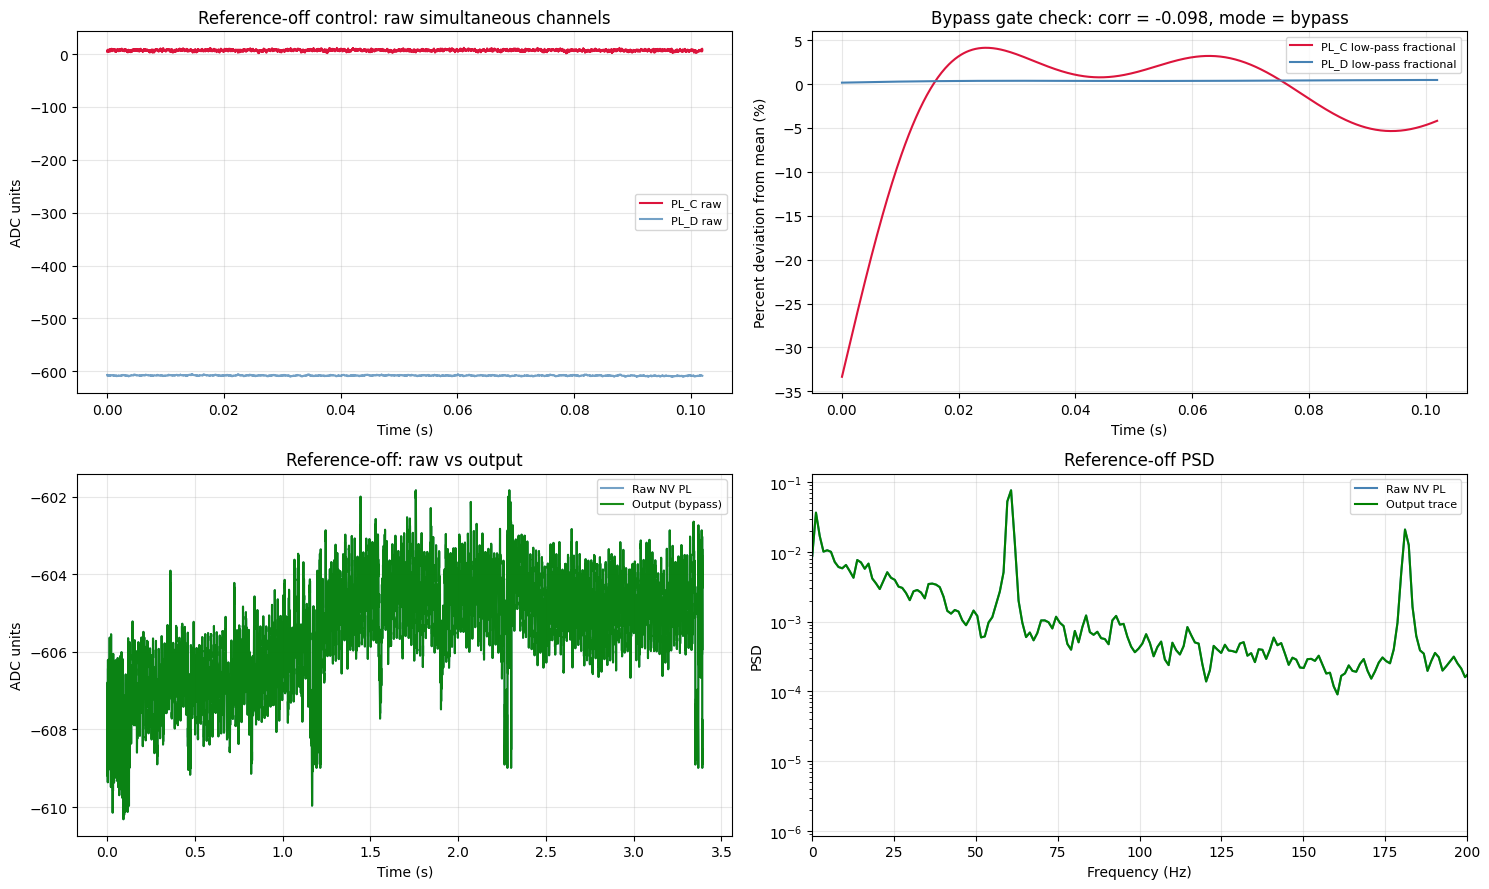

In [12]:
res = laser_off_ref_off.dataframe
sl = slice(0, min(4000, len(res)))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(res['time_s'].to_numpy(float)[sl], res['reference_raw_adc'].to_numpy(float)[sl], color='crimson', label='PL_C raw')
axes[0, 0].plot(res['time_s'].to_numpy(float)[sl], res['signal_raw_adc'].to_numpy(float)[sl], color='steelblue', label='PL_D raw', alpha=0.75)
axes[0, 0].set_title('Reference-off control: raw simultaneous channels')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('ADC units')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(res['time_s'].to_numpy(float)[sl], 100 * res['reference_fractional_low'].to_numpy(float)[sl], color='crimson', label='PL_C low-pass fractional')
axes[0, 1].plot(res['time_s'].to_numpy(float)[sl], 100 * res['signal_fractional_low'].to_numpy(float)[sl], color='steelblue', label='PL_D low-pass fractional')
axes[0, 1].set_title(f'Bypass gate check: corr = {laser_off_ref_off.corr_lowband:.3f}, mode = {laser_off_ref_off.mode}')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Percent deviation from mean (%)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(res['time_s'], res['signal_raw_adc'], color='steelblue', alpha=0.75, label='Raw NV PL')
axes[1, 0].plot(res['time_s'], res['corrected_nv_adc'], color='green', alpha=0.9, label=f'Output ({laser_off_ref_off.mode})')
axes[1, 0].set_title('Reference-off: raw vs output')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('ADC units')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=8)

for label, series, color in [
    ('Raw NV PL', res['signal_raw_adc'], 'steelblue'),
    ('Output trace', res['corrected_nv_adc'], 'green'),
]:
    freqs, psd = welch(series.to_numpy(float), fs=laser_off_ref_off.sample_rate_hz, nperseg=min(4096, len(res)))
    axes[1, 1].semilogy(freqs, psd, label=label, color=color)
axes[1, 1].set_xlim(0, 200)
axes[1, 1].set_title('Reference-off PSD')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('PSD')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()